# 🧠 TechMind
# Organização Inteligente de Conhecimento Técnico

## O Projeto

Criar uma solução (MVP funcional) que permita o enriquecimento e a organização inteligente de conteúdo técnico, facilitando sua classificação, consulta e reutilização. 

A solução deve utilizar técnicas de Ciência de Dados e integração com uma API

## Objetivo

• Criar e treinar modelos de classificação por categoria técnica

• Avaliar modelos e disponibilizar o de melhor performance para ser consumido via API

• Extração de palavras-chave

• Serialização do modelo e geração de .pkl

## Bibliotecas

In [ ]:
# Importa as Bibliotecas

# Manipulação de dados
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

## Obtendo Dados

In [6]:
# Carregando dados 
df = pd.read_csv('../dados/base_techmind.csv')
df.sample(5)

,texto,categoria
482,hello dev community officially day software en...,Database
1362,sudoku world popular logic puzzle . solve hand...,Frontend
1536,week agency site hit health score error ahref ...,Frontend
1543,path software developer not straight line . jo...,DataScience
1456,read brief challenge instinct build . fan need...,Frontend


### Conhecendo Dados e Estruturas

In [7]:
# Conhecendo dados e estrutura
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1637 entries, 0 to 1636
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   texto      1637 non-null   object
 1   categoria  1637 non-null   object
dtypes: object(2)
memory usage: 25.7+ KB


In [8]:
# Conferindo dados
df['categoria'].value_counts()

categoria
Backend        321
Security       319
Database       278
Frontend       276
Cloud          250
DataScience    193
Name: count, dtype: int64

## Pré Modelagem 

In [11]:
# Base para modelagem
df_model = df.copy()
df_model.shape

(1637, 2)

### Separação de Dados

Divisão da base em conjuntos de treino (80%) e teste (20%), utilizando `stratify=categoria` para preservar a proporção de cada categoria em ambos os conjuntos. Isso é importante devido o desbalanceamento entre classes (ex: DataScience possui bem menos registros que Backend).

In [18]:
# Split treino/teste (estratificado)
X_train, X_test, y_train, y_test = train_test_split(
    df_model['texto'],
    df_model['categoria'],
    test_size=0.2,
    random_state=42,
    stratify=df_model['categoria']
)

print(X_train.shape, X_test.shape)

(1309,) (328,)


In [15]:
# Validando proporção das categorias para treino (stratify)
print(y_train.value_counts(normalize=True))

# Validando proporção das categorias para teste (stratify)
print(y_test.value_counts(normalize=True))

categoria
Backend        0.196333
Security       0.194805
Database       0.169595
Frontend       0.168831
Cloud          0.152788
DataScience    0.117647
Name: proportion, dtype: float64
categoria
Backend        0.195122
Security       0.195122
Database       0.170732
Frontend       0.167683
Cloud          0.152439
DataScience    0.118902
Name: proportion, dtype: float64


Conferência das proporções de cada categoria em `y_train` e `y_test` para garantir que o `stratify` manteve a distribuição original da base. As proporções ficaram praticamente idênticas entre os dois conjuntos, confirmando que o split foi feito corretamente.

### TF-IDF (vetorização)

Transformação dos textos em vetores numéricos usando TF-IDF (Term Frequency - Inverse Document Frequency), que atribui peso maior a termos relevantes e discriminativos para cada categoria, e peso menor a termos muito comuns.

O vetorizador é ajustado (`fit_transform`) apenas nos dados de treino, e aplicado (`transform`) nos dados de teste, evitando vazamento de informação do teste para o treino.

In [17]:
# TF-IDF Vectorization
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(X_train_tfidf.shape, X_test_tfidf.shape)

(1309, 5000) (328, 5000)


Parâmetros escolhidos:
- `max_features=5000`: limita o vocabulário aos 5000 termos mais relevantes, evitando ruído de palavras raras
- `ngram_range=(1, 2)`: considera palavras isoladas e pares de palavras, capturando um pouco mais de contexto

*(stopwords não são reaplicadas aqui pois já foram removidas na limpeza via spaCy)*

## Modelo Logistic Regression

### Modelagem - Logistic Regression (baseline)

#### Criação do Modelo

In [20]:
# Cria modelo de classificação 
modelo_lr = LogisticRegression(
    max_iter=1000, 
    random_state=42
)

#### Validação Cruzada (Cross-Validation)

Antes de avaliar o modelo no conjunto de teste, aplicamos validação cruzada (5-fold) nos dados de treino para verificar se o desempenho do modelo é consistente, evitando conclusões baseadas em um único split.

Utilizamos `f1_macro` como métrica, por ponderar igualmente todas as categorias, mais adequada que a acurácia dado o desbalanceamento da base.

In [23]:
scores_lr = cross_val_score(
    modelo_lr, X_train_tfidf, y_train, cv=5, scoring='f1_macro'
)

print(f"F1 macro: {scores_lr.mean():.4f} (+/- {scores_lr.std():.4f})")

F1 macro: 0.7650 (+/- 0.0168)


A validação cruzada apresentou F1 macro médio de 0.7650, com desvio padrão de 0.0168 entre os 5 folds. O desvio baixo indica que o desempenho do modelo Logistic Regression é consistente independente de quais dados caem em cada fold, reforçando a confiabilidade do resultado antes de avaliarmos o modelo no conjunto de teste.

#### Treinamento do modelo

In [24]:
# Treino do modelo Logistic Regression com balanceamento de classes
modelo_lr.fit(
    X_train_tfidf,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


#### Avaliação do Modelo  - Logistic Regression (baseline)

Avaliação do desempenho do modelo nos dados de teste, utilizando métricas por categoria (precision, recall, F1-score), já que a base possui desbalanceamento entre classes o accuracy geral sozinho não seria suficiente para avaliar corretamente o modelo.

In [ ]:
# Predição nos dados de teste
y_pred_lr = modelo_lr.predict(X_test_tfidf)

In [27]:
# Métricas de avaliação
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

     Backend       0.57      0.70      0.63        64
       Cloud       0.95      0.84      0.89        50
 DataScience       0.78      0.46      0.58        39
    Database       0.80      0.80      0.80        56
    Frontend       0.70      0.73      0.71        55
    Security       0.84      0.91      0.87        64

    accuracy                           0.76       328
   macro avg       0.78      0.74      0.75       328
weighted avg       0.77      0.76      0.76       328



O modelo de Regressão Logística obteve 76% de acurácia no conjunto de teste, resultado consistente com o F1 macro de 0.7650 estimado na validação cruzada. Como a base apresenta desbalanceamento entre categorias, a análise por classe (precision, recall e F1-score) é mais informativa que a acurácia geral isoladamente:

* Melhor desempenho: Cloud (F1 0.89) e Security (F1 0.87), com alta precision e recall, indicando que o modelo distingue bem os termos dessas categorias
* Desempenho intermediário: Database (F1 0.80) e Frontend (F1 0.71)
* Pior desempenho: DataScience (F1 0.58) e Backend (F1 0.63)

O caso de DataScience é coerente com o desbalanceamento da base, pois é a categoria com menos registros de treino (193), o que se reflete no recall baixo (0.46): o modelo está deixando passar boa parte dos textos dessa categoria, classificando-os incorretamente em outras.

Já Backend apresenta o padrão inverso: recall razoável (0.70), mas precision baixa (0.57), sugerindo que o modelo está classificando como Backend textos que, na verdade, pertencem a outras categorias, gerando possível indício de sobreposição de vocabulário técnico com Database e Cloud.

As métricas macro avg (média simples entre categorias) e weighted avg (média ponderada pelo número de exemplos de cada categoria) ficaram próximas (0.75 e 0.76, respectivamente), reforçando que o desempenho está relativamente equilibrado entre classes, apesar do desbalanceamento da base.

##### Matriz de Confusão

Visualização de quais categorias o modelo mais confunde entre si, complementando a análise de precision/recall por classe.

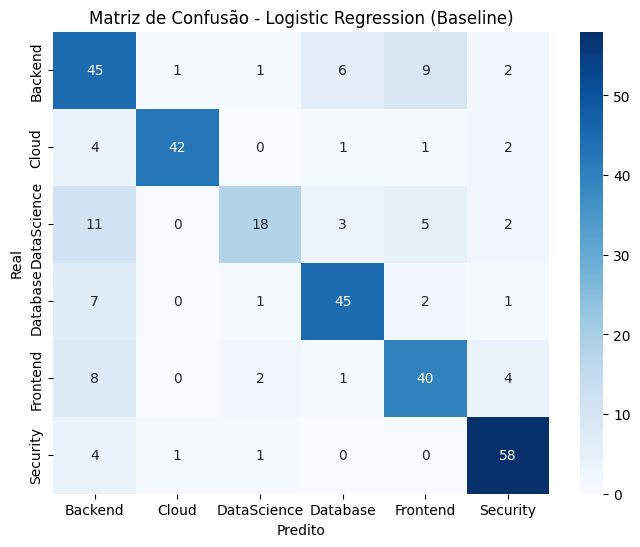

In [30]:
cm = confusion_matrix(y_test, y_pred_lr, labels=modelo_lr.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=modelo_lr.classes_, yticklabels=modelo_lr.classes_)
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão - Logistic Regression (Baseline)')
plt.show()

A matriz de confusão confirma o padrão observado nas métricas: 

* DataScience é confundida principalmente com Backend (11 casos)
* Backend recebe erros vindos de várias categorias (DataScience, Frontend, Database), sugerindo sobreposição de vocabulário técnico entre elas. 
* Security e Cloud, por outro lado, apresentam baixíssima confusão cruzada, confirmando seu bom desempenho.

O modelo baseline de Regressão Logística obteve um desempenho consistente e razoável (76% de acurácia, F1 macro 0.75), mas apresentou fragilidade evidente na categoria DataScience, tanto nas métricas quanto na matriz de confusão. Esse resultado motiva testar o parâmetro class_weight='balanced', que ajusta o peso das classes durante o treino de forma inversamente proporcional à frequência de cada categoria. A ideia é tentar compensar o desbalanceamento da base e melhorar o desempenho em categorias minoritárias como DataScience.

### Modelagem - Logistic Regression (com class_weight='balanced')

#### Criando Modelo 

In [31]:
# Criando modelo 
modelo_lr_balanced = LogisticRegression(max_iter=1000, 
                                        random_state=42, 
                                        class_weight='balanced')

#### Validação Cruzada (Cross-Validation) - Modelo com class_weight='balanced'

In [32]:
# Cross-validation
scores_lr_balanced = cross_val_score(
    modelo_lr_balanced, X_train_tfidf, y_train, cv=5, scoring='f1_macro'
)

print(f"F1 macro: {scores_lr_balanced.mean():.4f} (+/- {scores_lr_balanced.std():.4f})")

F1 macro: 0.7705 (+/- 0.0090)


A validação cruzada do modelo com class_weight='balanced' apresentou F1 macro médio de 0.7705, com desvio padrão de 0.0090 entre os 5 folds. Comparado ao baseline (F1 macro 0.7650, desvio 0.0168), o modelo balanced teve desempenho médio ligeiramente superior e maior estabilidade entre os folds, o que reforça a decisão de seguir com essa configuração para a avaliação final no conjunto de teste.

#### Treinamento do modelo

In [33]:
# Treino
modelo_lr_balanced.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


### Comparação - Avaliação dos Modelos Logistic Regression

In [ ]:
# Predição Modelo com balanced
y_pred_lr_balanced = modelo_lr_balanced.predict(X_test_tfidf)

In [40]:
# Métricas de avaliação dos modelos (sem e com class_weight='balanced') 

# Gerando os relatórios como DataFrame
report_baseline = pd.DataFrame(classification_report(y_test, y_pred_lr, output_dict=True)).transpose()
report_balanced = pd.DataFrame(classification_report(y_test, y_pred_lr_balanced, output_dict=True)).transpose()

# Comparando performance dos dois modelos
comparacao = pd.concat([report_baseline, report_balanced], axis=1, keys=['Baseline', 'Balanced'])
comparacao.round(2)

Baseline                          Balanced                  \
             precision recall f1-score support precision recall f1-score   
Backend           0.57   0.70     0.63   64.00      0.61   0.67     0.64   
Cloud             0.95   0.84     0.89   50.00      0.93   0.84     0.88   
DataScience       0.78   0.46     0.58   39.00      0.67   0.62     0.64   
Database          0.80   0.80     0.80   56.00      0.81   0.79     0.80   
Frontend          0.70   0.73     0.71   55.00      0.72   0.75     0.73   
Security          0.84   0.91     0.87   64.00      0.85   0.88     0.86   
accuracy          0.76   0.76     0.76    0.76      0.76   0.76     0.76   
macro avg         0.78   0.74     0.75  328.00      0.77   0.76     0.76   
weighted avg      0.77   0.76     0.76  328.00      0.77   0.76     0.76   

                      
             support  
Backend        64.00  
Cloud          50.00  
DataScience    39.00  
Database       56.00  
Frontend       55.00  
Security       64.00  
accuracy        0.76  
macro avg     328.00  
weighted avg  328.00

#### Comparação - Matriz de Confusão

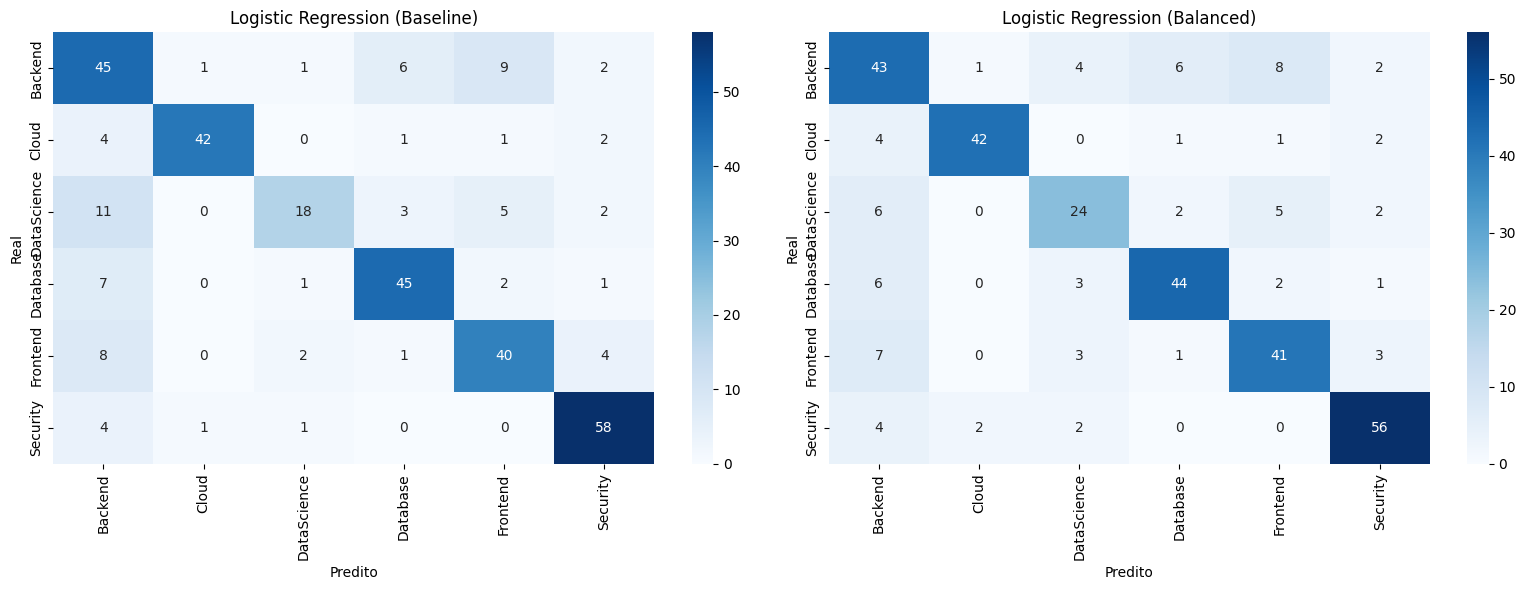

In [41]:
# Comparando as matrizes de confusão 
cm = confusion_matrix(y_test, y_pred_lr, labels=modelo_lr.classes_)
cm_balanced = confusion_matrix(y_test, y_pred_lr_balanced, labels=modelo_lr_balanced.classes_)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=modelo_lr.classes_, yticklabels=modelo_lr.classes_,
            ax=axes[0])
axes[0].set_xlabel('Predito')
axes[0].set_ylabel('Real')
axes[0].set_title('Logistic Regression (Baseline)')

sns.heatmap(cm_balanced, annot=True, fmt='d', cmap='Blues',
            xticklabels=modelo_lr_balanced.classes_, yticklabels=modelo_lr_balanced.classes_,
            ax=axes[1])
axes[1].set_xlabel('Predito')
axes[1].set_ylabel('Real')
axes[1].set_title('Logistic Regression (Balanced)')

plt.tight_layout()
plt.show()

Comparando as duas matrizes, fica visível a melhora em DataScience, onde os acertos subiram de 18 para 24, e a confusão com Backend caiu de 11 para 6 casos. 

Em contrapartida, Backend recebeu um pouco mais de confusão vinda de DataScience (4 → 6) e teve uma leve queda nos acertos (45 → 43). 

Cloud e Security permaneceram praticamente inalterados nos dois modelos.

Por melhorar o ponto mais fraco do modelo sem prejudicar as demais categorias, esse será considerado o modelo final da regressão logistica.

## Modelo Naive Bayes

In [42]:
# AGUARANDO 

## Modelo SVM 

In [ ]:
# AGUARANDO 

## Comparação dos Modelos

AGUARDANDO DESENVOLVIMENTOS DOS DEMAIS MODELOS PARA COMPARAÇÃO 

## Extração de Palavras-Chave

A extração das palavras chave é realizada reaproveitando o mesmo vetor TF-IDF aplicado no treinamento do modelo. É possível extrair as palavras mais relevantes do texto, identificando os termos com maior peso (score TF-IDF) para aquele texto específico. Esses termos podem ser utilizados para facilitar buscas, organização e reutilização do conhecimento dentro da plataforma TechMind.

In [50]:
def extrair_palavras_chave(texto, vectorizer, top_n=5):
    # Transforma o texto em vetor TF-IDF usando o vectorizer já treinado
    tfidf_vector = vectorizer.transform([texto])
    
    # Extrai os pesos TF-IDF do texto (matriz esparsa vira array simples de números)
    scores = tfidf_vector.toarray()[0]

    # Recupera os termos existentes no TF-IDF
    termos = vectorizer.get_feature_names_out()
    
    # Pega os índices dos termos com maior peso, em ordem decrescente
    top_indices = scores.argsort()[-top_n:][::-1]
    
    # Retorna as palavras ordenadas por relevância
    palavras_chave = [termos[i] for i in top_indices if scores[i] > 0]

    # Se quiser ver com o indice
    #palavras_chave = [(termos[i], round(scores[i], 3)) for i in top_indices if scores[i] > 0]
    
    return palavras_chave

In [51]:
# Testando a extração de palavras-chave em alguns exemplos
resultados = []

for i in range(5):
    texto = X_test.iloc[i]
    categoria = y_test.iloc[i]
    palavras_chave = extrair_palavras_chave(texto, vectorizer, top_n=3)
    resultados.append({'categoria': categoria, 'palavras_chave': palavras_chave})

df_palavras_chave = pd.DataFrame(resultados)
df_palavras_chave

,categoria,palavras_chave
0,Backend,"[qr, yes, net]"
1,Cloud,"[cloud, azure, service]"
2,Frontend,"[red, literal, detector]"
3,Backend,"[contract, client, break change]"
4,Backend,"[option, product, price]"


Testando a função de extração de palavras-chave em uma amostra do conjunto de teste, alguns resultados foram coerentes com a categoria real, como Cloud (cloud, azure, service) e Backend (contract, client, break change).

Porém, em outros casos, há termos genéricos ou de baixa relevância semântica, como yes ou red, literal, detector. Isso reflete duas limitações da abordagem: 

* o TF-IDF é uma métrica estatística e não compreende o significado dos termos, por isso pode atribuir peso alto a palavras sem relevância técnica real, como resíduos de linguagem natural que passaram pela limpeza. 
* a sobreposição natural de vocabulário técnico entre categorias (já observada na etapa de classificação) também impacta a extração, resultando em palavras-chave mais genéricas para textos de categorias como Backend.

PENDENTE: MELHORAR EXTRAÇÃO PALAVRAS CHAVE

## Estrutura do Retorno do Modelo

O objetivo é preparar e simular a saída que será consumida pela API da aplicação, reunindo:

- Categoria prevista pelo modelo de classificação;
- Probabilidade associada à previsão;
- Palavras-chave extraídas do conteúdo analisado.

Esse teste considera os dados em memória

In [64]:
# Função simulação 
def analisar_conteudo(texto):
    
    # Transformar texto para o formato do modelo
    texto_tfidf = vectorizer.transform([texto])
    
    # Categoria prevista
    categoria = modelo_lr_balanced.predict(texto_tfidf)[0]
    
    # Probabilidade da previsão
    probabilidades = modelo_lr_balanced.predict_proba(texto_tfidf)[0]
    probabilidade = float(probabilidades.max())
    
    # Palavras-chave
    palavras_chave = extrair_palavras_chave(
        texto,
        vectorizer,
        top_n=3
    )
    
    return {
        "categoria": str(categoria),
        "probabilidade": round(probabilidade, 2),
        "informacoes_adicionais": palavras_chave
    }

In [65]:
# definindo texto teste
texto_teste = df_model.loc[0, 'texto']

In [66]:
# Simulando o retorno
resultado = analisar_conteudo(texto_teste)
resultado

{'categoria': 'Security',
 'probabilidade': 0.61,
 'informacoes_adicionais': ['ssh', 'mfa', 'google']}

### Análise da Probabilidade de Classificação

In [67]:
# Verificando todas as probabilidades do texto teste
probabilidades = modelo_lr_balanced.predict_proba(
    vectorizer.transform([texto_teste])
)[0]

df_prob = pd.DataFrame({
    'Categoria': modelo_lr_balanced.classes_,
    'Probabilidade': probabilidades
})

df_prob['Probabilidade'] = df_prob['Probabilidade'].round(4)

df_prob = df_prob.sort_values(
    by='Probabilidade',
    ascending=False
)

df_prob

,Categoria,Probabilidade
5,Security,0.6127
0,Backend,0.1023
1,Cloud,0.0979
3,Database,0.0761
4,Frontend,0.0691
2,DataScience,0.0419


O modelo retorna a distribuição de probabilidades entre todas as classes possíveis. Neste exemplo, a categoria Security apresentou a maior probabilidade de classificação (61,27%), enquanto as demais categorias apresentaram valores inferiores. Essa informação permite avaliar o nível de confiança associado à previsão realizada pelo modelo.

A probabilidade será utilizada como uma informação adicional no retorno da API, permitindo que aplicações consumidoras tenham visibilidade sobre o grau de confiança da classificação.

## Serialização do Modelo

A serialização permite salvar o modelo treinado e o vetor TF-IDF em arquivo persistente, possibilitando que a aplicação Back-End carregue esses componentes sem a necessidade de realizar novamente o treinamento.

Serão armazenados:

- Modelo de classificação balanceado (`modelo_lr_balanced`);
- Vetorizador TF-IDF (`vectorizer`).

O arquivo .pkl armazendo será utilizado posteriormente pela API da aplicação Techmind para realizar novas classificações de conteúdos técnicos, juntamente com a extração das palavras-chave e geração das informações de retorno.

In [ ]:
# Gerando arquivo .pkl
artefatos_modelo = {
    "modelo": modelo_lr_balanced,
    "vectorizer": vectorizer
}

joblib.dump(
    artefatos_modelo,
    '../modelo/modelo_techmind.pkl'
)

['../modelo/modelo_techmind.pkl']

## Exemplos de Uso (JSON)

Nesta etapa será simulada a utilização do modelo em um cenário próximo ao funcionamento da API.

Serão enviados exemplos de conteúdos técnicos como entrada, representando requisições realizadas por usuários. O modelo realizará a classificação do conteúdo, calculará a probabilidade da previsão e retornará as palavras-chave identificadas.

A saída será estruturada em formato JSON, seguindo o padrão esperado para integração com a aplicação Backend.

In [69]:
# Simula o consumo o arquivo .pkl
artefatos = joblib.load('../modelo/modelo_techmind.pkl')

modelo = artefatos["modelo"]
vectorizer = artefatos["vectorizer"]

In [70]:
# Confirma que os artefatos foram carregados corretamente a partir do .pkl
type(modelo), type(vectorizer)

(sklearn.linear_model._logistic.LogisticRegression,
 sklearn.feature_extraction.text.TfidfVectorizer)

In [72]:
# Texto Teste
textos_teste = (
    df_model['texto']
    .sample(3, random_state=42)
    .tolist()
)

textos_teste

['retrieve rich xiaohongshu note datum python tutorial retrieve normalize public note datum complete xiaohongshu rednote url rapidapi . need - subscription xhs data api . - server - rapidapi key . - current public note url contain xsec_token copy note . value environment variable validate url noteparse_url perform local validation extract url component fetch upstream note datum retrieve normalize detail normalize note contract include author identity description engagement count tag timestamp location image video music medium dimension public source supply . understand miss field null mean select upstream page provide field . zero . optional location music video engagement field legitimately unavailable . medium url sign temporary . use promptly treat permanent storage . handle failure data.request_id error . retryable request_timeout include retry - wait interval retry identical request . note token expire obtain current complete public url instead invent transfer token . complete pyt

In [75]:
def analisar_conteudo_api(texto, modelo, vectorizer):
    
    texto_tfidf = vectorizer.transform([texto])
    
    categoria = modelo.predict(texto_tfidf)[0]
    
    probabilidade = modelo.predict_proba(texto_tfidf).max()
    
    palavras_chave = extrair_palavras_chave(
        texto,
        vectorizer,
        top_n=3
    )
    
    return {
        "categoria": str(categoria),
        "probabilidade": float(probabilidade),
        "informacoes_adicionais": palavras_chave
    }

In [76]:
# Simulando resultado
import json

resultados_json = []

for texto in textos_teste:
    
    resultado = analisar_conteudo_api(
        texto,
        modelo,
        vectorizer
    )
    
    resultados_json.append(resultado)


print(json.dumps(resultados_json, indent=4, ensure_ascii=False))

[
    {
        "categoria": "Backend",
        "probabilidade": 0.33101551653474975,
        "informacoes_adicionais": [
            "note",
            "url",
            "public"
        ]
    },
    {
        "categoria": "Backend",
        "probabilidade": 0.4629713483580124,
        "informacoes_adicionais": [
            "keycloak",
            "spring",
            "role"
        ]
    },
    {
        "categoria": "Frontend",
        "probabilidade": 0.46289801318047175,
        "informacoes_adicionais": [
            "auth",
            "supabase",
            "db"
        ]
    }
]


O retorno da integração do modelo apresentou a classificação dos conteúdos analisados juntamente com a probabilidade associada e as principais palavras-chave extraídas pelo TF-IDF.

Os resultados demonstram que o modelo conseguiu gerar as previsões utilizando os artefatos carregados a partir do arquivo `.pkl`, mantendo a integração entre o modelo de classificação e o vetor TF-IDF utilizado no treinamento.

As probabilidades retornadas indicam o nível de confiança da classificação para cada conteúdo analisado, enquanto as palavras-chave destacam os termos mais relevantes identificados na representação vetorial do texto.

Essa estrutura representa o formato esperado para o consumo pela API, permitindo retornar não apenas a categoria prevista, mas também informações adicionais para interpretação do resultado.

## Conclusões

In [77]:
# PENDENTE DEMAIS MODELOS 